# Product-Inventory Problem Test

In [235]:
import lropt

In [236]:
import cvxpy as cp

import matplotlib.pyplot as plt
import numpy as np
import numpy.random as npr
import numpy.testing as npt
import scipy as sc
import torch
from sklearn.model_selection import train_test_split

In [237]:
seed = 15
np.random.seed(seed)
kappa = -0.01
n = 2 # number of time periods

# family parameter (production costs)
dist = [1-0.5*np.sin(np.pi*(t-1)/12) for t in range(1, n+1)]
sig = np.random.rand(n, n)
sig = np.dot(sig, sig.T) # to ensure symmetric positive definiteness
y_data = np.random.multivariate_normal(dist, sig, 10)

In [238]:
# uncertainty distribution
def gen_demand_intro(N, seed):
    np.random.seed(seed)
    theta = 0.025
    d_hat = [1000*(1+0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, n+1)] # nominal demand
    d_train = d_hat * np.random.uniform(1-theta, 1+theta, (N, n))
    return d_hat, d_train

In [239]:
# initialize problem
P = np.full(n, 567) # max production capacity at each time period
Q = 1100 # max production capacity for all periods
V_min = 500 # minimum inventory
V_max = 2000 # maximum inventory
v_1 = 2000 # initial inventory
d_hat, data = gen_demand_intro(100, seed=15) # demand
print(d_hat)

[1000.0, 1129.4095225512604]


## Problem with Known Demand ("Ideal" Case)

In [119]:
print(dist) # costs

[1.0, 0.8705904774487396]


In [120]:
opt_objectives = []
opt_x = []

# 100 simulations (demands drawn at random, according to uniform dist.)
for demand in data:
    x = cp.Variable(n)
    u = demand
    objective = cp.Minimize(x @ dist)
    constraints = [cp.sum(x) <= Q, x >=0, x<= P]
    for t in range(n):
        b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
        constraints.append(x @ b - u @ b >= V_min - v_1)
        constraints.append(x @ b - u @ b <= V_max - v_1)
    
    prob = cp.Problem(objective, constraints)
    prob.solve()
    opt_objectives.append(prob.value)
    opt_x.append(x.value)

In [121]:
print(data[0]) # demand
print(opt_objectives[0]) # objective
print(opt_x[0]) # optimal x

[1017.44088486 1111.27662255]
555.3423083005029
[ 61.71750768 566.9999999 ]


In [122]:
print("Production Cost Mean: ", np.mean(opt_objectives))
print("Production Cost Std: ", np.std(opt_objectives))

Production Cost Mean:  553.2615582619177
Production Cost Std:  22.31580301377204


Above results have been checked (matches intuitive optimal solutions).

## Problem with Uncertain Demand (AARC)

In [123]:
d_hat

[1000.0, 1129.4095225512604]

In [125]:
# used to check accuracy of below aarc method
def aarc_online_manual(theta):
    pi_0 = cp.Variable(n)
    q_1 = cp.Variable()
    q_2 = cp.Variable()
    q_3 = cp.Variable()
    
    obj = pi_0 @ dist + (1 + theta) * (dist[0]*q_1*d_hat[0] + dist[1]*q_2*d_hat[0] + dist[1]*q_3*d_hat[1])
    objective = cp.Minimize(obj)

    constraints = []
    c1 = cp.sum(pi_0) + (1 + theta) * (q_1*d_hat[0] + q_2*d_hat[0] + q_3*d_hat[1])
    constraints.append(c1 <= Q)
    constraints.append(c1 - (1 - theta) * (d_hat[0] + d_hat[1]) <= V_max - v_1)
    constraints.append(c1 - (1 + theta) * (d_hat[0] + d_hat[1]) >= V_min - v_1)
    constraints.append(pi_0[0] - (1 - theta) * d_hat[0] <= V_max - v_1)
    constraints.append(pi_0[0] - (1 + theta) * d_hat[0] >= V_min - v_1)
    constraints.append(pi_0[0] + (1 + theta) * q_1 * d_hat[0] <= P[0])
    constraints.append(pi_0[0] + (1 - theta) * q_1 * d_hat[0] >= 0)
    constraints.append(pi_0[1] + (1 + theta) * (q_2 * d_hat[0] + q_3 * d_hat[1]) <= P[1])
    constraints.append(pi_0[1] + (1 - theta) * (q_2 * d_hat[0] + q_3 * d_hat[1]) >= 0)

    prob = cp.Problem(objective, constraints)
    print(prob.solve())

In [126]:
aarc_online_manual(theta = 0.01) # richest "on-line" information basis

577.3284185085504


In [127]:
# k is the information lag
def aarc(theta, k):
    I = 1
    pi_0 = cp.Variable((I, n))
    phi = cp.Variable((I, n*n))

    obj = pi_0 @ dist
    constraints = []
    c1 = cp.sum(pi_0, axis = 1)
    c2 = []
    for t in range(n):
        A = np.zeros((n, n))
        if (t - k >= 0):
            A[:t-k, :t-k] = np.identity(t - k)
            
        obj += (1 + theta) * (dist[t] * phi[:, n*t:n*(t+1)] @ A @ d_hat)
        c1 += (1 + theta) * (phi[:, n*t:n*(t+1)] @ A @ d_hat)
        constraints.append(pi_0[:, t] + (1 + theta) * (phi[:, n*t:n*(t+1)] @ A @ d_hat) <= P[t])
        constraints.append(pi_0[:, t] + (1 - theta) * (phi[:, n*t:n*(t+1)] @ A @ d_hat) >= 0)
        c2.append(np.ones(I) @ phi[:, n*t:n*(t+1)] @ A @ d_hat)
    
    objective = cp.Minimize(obj)
    constraints.append(c1 <= Q)
        
    for t in range(n):
        b = np.concatenate((np.ones(t + 1), np.zeros(n - t - 1)))
        constraints.append((np.ones(I) @ pi_0) @ b - (1 - theta) * (b.T @ d_hat) + (1 - theta) * (c2 @ b) <= V_max - v_1)
        constraints.append((np.ones(I) @ pi_0) @ b - (1 + theta) * (b.T @ d_hat) + (1 + theta) * (c2 @ b) >= V_min - v_1)

    prob = cp.Problem(objective, constraints)
    print(prob.solve())

In [128]:
aarc(theta = 0.01, k = 0) # richest "on-line" information basis

577.3284185064549


In [132]:
aarc(theta = 0.025, k = 1) # standard information basis (knowing complete past demands)

609.2695614306052


In [134]:
# ideal case
x = cp.Variable(n)
objective = cp.Minimize(x @ dist)
constraints = [cp.sum(x) <= Q, x >=0, x<= P]
for t in range(n):
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    constraints.append(x @ b - d_hat @ b >= V_min - v_1)
    constraints.append(x @ b - d_hat @ b <= V_max - v_1)
    
prob = cp.Problem(objective, constraints)
prob.solve()

556.0343234585173

As expected, compared to the ideal case, the ARO optimal objective (609.27) is still above the ideal production cost (556.03), where there is no uncertainty in the demand.

## Using LROPT

In [240]:
# y = lropt.Parameter(n, data = y_data) 
y = lropt.Parameter(n, data = np.array([dist])) # only looking at one cost case
u = lropt.UncertainParameter(n, uncertainty_set=lropt.Box(data=data))
x = cp.Variable(n)
objective = cp.Minimize(x @ y)
constraints = [cp.sum(x) <= Q, x >= 0, x <= P]
for t in range(n):
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    constraints.append(x @ b - u @ b >= V_min - v_1)
    constraints.append(x @ b - u @ b <= V_max - v_1)
prob = lropt.RobustProblem(objective, constraints)

In [241]:
test_p = 0.1
s = 15
train, _ = train_test_split(data, test_size=int(data.shape[0]*test_p), random_state=s)

init = sc.linalg.sqrtm(sc.linalg.inv(np.cov(train.T)))
init_bval= -init@np.mean(train, axis=0)
np.random.seed(15)
initn = np.random.rand(n, n) + 0.1*init + 0.5*np.eye(n)
init_bvaln = -initn@(np.mean(train, axis=0) - 0.3*np.ones(n))

### Original LROPT

In [163]:
# Train A and b
result = prob.train(lr=0.001, num_iter=100, momentum=0.8, # increase numbe of iterations
                    optimizer="SGD",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = True, random_init=True, num_random_init=2, position = True)


run 1: test value 555.94, violations 0.4: 100%|██████████| 100/100 [00:01<00:00, 84.35it/s]


In [164]:
results_df = result.df
df_test = result.df_test

In [165]:
result.weights

[tensor([[ 1.5410, -0.2934],
         [-2.1788,  0.5684]], dtype=torch.float64),
 tensor([-1.0845, -1.3986], dtype=torch.float64)]

In [166]:
result.var_values # x

(tensor([[ 60.5682, 567.0000]], dtype=torch.float64, requires_grad=True),)

In [167]:
result.obj

554.1929994000086

### Modified LROPT (Fixed initial values)

In [227]:
# Train A and b
result = prob.train(lr=0.001, num_iter=100, momentum=0.8, # increase numbe of iterations
                    optimizer="SGD",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = True, random_init=True, num_random_init=2, position = True)

HERE_A tensor([[0.2333, 0.5232],
        [0.5507, 0.0556]], dtype=torch.float64, requires_grad=True) HERE_B tensor([-822.6857, -613.2141], dtype=torch.float64, requires_grad=True)
HERE_A tensor([[1.3552, 0.1789],
        [0.0544, 0.8680]], dtype=torch.float64, requires_grad=True) HERE_B tensor([-1556.0293, -1032.0964], dtype=torch.float64, requires_grad=True)



run 0: test value 554.235, violations 0.4: 100%|██████████| 100/100 [00:01<00:00, 94.38it/s]


In [228]:
result.var_values

(tensor([[ 60.6100, 567.0000]], dtype=torch.float64, requires_grad=True),)

In [229]:
result.weights

[tensor([[1.3552, 0.1789],
         [0.0544, 0.8680]], dtype=torch.float64),
 tensor([-1556.0293, -1032.0964], dtype=torch.float64)]

In [230]:
result.obj

554.2347976533397

In [231]:
result.df

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",554.2548,554.234798,0.569444,0.01,"(1.6201714754926404,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(0.0,)","([-0.0005001, -0.0005001, -0.0005001, -0.00050...","(tensor(2.0004),)","(1492.9125457930932,)","([[tensor([-611.4593, -689.3226], dtype=torch...."
1,"(1,)",554.250801,554.234798,0.541667,0.008,"(1.6201714754926404,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.0020004000980407,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0007),)","(1492.9125457930932,)","([[tensor([-611.4593, -689.3226], dtype=torch...."
2,"(2,)",554.243597,554.234798,0.541667,0.004399,"(1.6201714754926404,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.00560144055634737,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0006),)","(1492.9125457930932,)","([[tensor([-611.4593, -689.3226], dtype=torch...."
3,"(3,)",554.233832,554.234798,0.555556,-0.000483,"(1.6201714754926404,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.010482849553227425,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(1492.9125457930932,)","([[tensor([-611.4593, -689.3226], dtype=torch...."
4,"(4,)",554.222019,554.234798,0.513889,-0.006388,"(1.6201714754926404,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.016388356685638428,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0001),)","(1492.9125457930932,)","([[tensor([-611.4593, -689.3226], dtype=torch...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",552.464737,554.234798,0.5,-0.892856,"(1.6201714754926404,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9028556942939758,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9645),)","(1492.9125457930932,)","([[tensor([-611.4593, -689.3226], dtype=torch...."
96,"(96,)",552.445426,554.234798,0.541667,-0.902686,"(1.6201714754926404,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.912686288356781,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9641),)","(1492.9125457930932,)","([[tensor([-611.4593, -689.3226], dtype=torch...."
97,"(97,)",552.426123,554.234798,0.5,-0.912515,"(1.6201714754926404,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9225149154663086,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9638),)","(1492.9125457930932,)","([[tensor([-611.4593, -689.3226], dtype=torch...."
98,"(98,)",552.406828,554.234798,0.527778,-0.922342,"(1.6201714754926404,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9323415756225586,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9634),)","(1492.9125457930932,)","([[tensor([-611.4593, -689.3226], dtype=torch...."


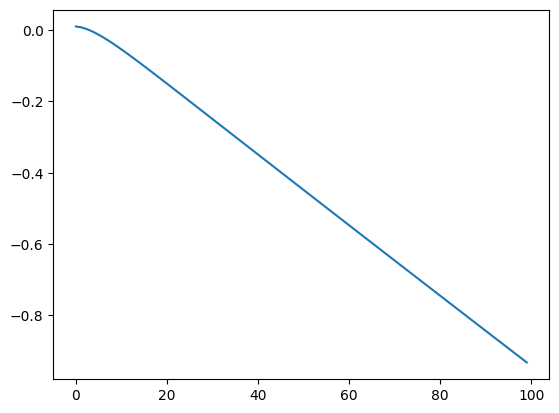

In [234]:
plt.plot(result.df["Violations_train"])

#### Random Initialization

In [242]:
# Train A and b
result = prob.train(lr=0.001, num_iter=100, momentum=0.8, # increase numbe of iterations
                    optimizer="SGD",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = True, random_init=True, num_random_init=2, position = True)

HERE_A tensor([[1.3552, 0.1789],
        [0.0544, 0.8680]], dtype=torch.float64, requires_grad=True) HERE_B tensor([-1556.0293, -1032.0964], dtype=torch.float64, requires_grad=True)
HERE_A tensor([[0.2333, 0.5232],
        [0.5507, 0.0556]], dtype=torch.float64, requires_grad=True) HERE_B tensor([-822.6857, -613.2141], dtype=torch.float64, requires_grad=True)



run 1: test value 0.0, violations 1.0: 100%|██████████| 100/100 [00:01<00:00, 93.95it/s]


In [243]:
result.var_values

(tensor([[1.3359e-09, 8.5398e-10]], dtype=torch.float64, requires_grad=True),)

In [244]:
result.weights

[tensor([[ 1.5410, -0.2934],
         [-2.1788,  0.5684]], dtype=torch.float64),
 tensor([-1.0845, -1.3986], dtype=torch.float64)]

In [245]:
result.obj

2.0793254505339805e-09

In [248]:
result.df

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",0.020002,0.0,1.0,0.01,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(0.0,)","([-0.0005001, -0.0005001, -0.0005001, -0.00050...","(tensor(2.0004),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
1,"(1,)",0.016004,0.0,1.0,0.008,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.0020004000980407,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0007),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
2,"(2,)",0.008799,0.0,1.0,0.004399,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.00560144055634737,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0006),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
3,"(3,)",-0.000966,0.0,1.0,-0.000483,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.010482849553227425,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
4,"(4,)",-0.012778,0.0,1.0,-0.006388,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.016388356685638428,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0001),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",-1.770061,0.0,1.0,-0.892856,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9028556942939758,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9645),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
96,"(96,)",-1.789372,0.0,1.0,-0.902686,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.912686288356781,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9641),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
97,"(97,)",-1.808674,0.0,1.0,-0.912515,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9225149154663086,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9638),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
98,"(98,)",-1.82797,0.0,1.0,-0.922342,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9323415756225586,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9634),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
